<a href="https://colab.research.google.com/github/vikobaldigi/DATA-71200-Advanced-Data-Analysis-Methods-Project/blob/main/Project%201/KovacevicVi_Project1_10_31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Dataset

In [10]:
# Load NYC Schools Dataset from GitHub
url = 'https://raw.githubusercontent.com/vikobaldigi/DATA-71200-Advanced-Data-Analysis-Methods-Project/main/data/schools_curated.csv'
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1183, 40)


,DBN,School_Name,Subject,MeanScore,Leadership_Count,Teacher_Count,Other_Staff_Count,Total_Staff,Male_Teachers,Male_Avg_Years_Title,...,Black_Percent,Hispanic_Percent,White_Percent,latitude,longitude,ZIP Code_x,School Type,School Level,Neighborhood,ZIP Code_y
0,02M260,THE CLINTON SCHOOL,common_core_algebra,62.698333,3.0,56.0,11.0,70.0,13.0,9.0,...,16.718333,83.281667,0.00000,40.832508,-73.878191,10472.0,General Academic,High school,Pelham - Throgs Neck,10472
1,02M260,THE CLINTON SCHOOL,common_core_english,74.016667,3.0,56.0,11.0,70.0,13.0,9.0,...,16.718333,83.281667,0.00000,40.832508,-73.878191,10472.0,General Academic,High school,Pelham - Throgs Neck,10472
2,02M260,THE CLINTON SCHOOL,living_environment,63.816667,3.0,56.0,11.0,70.0,13.0,9.0,...,16.718333,83.281667,0.00000,40.832508,-73.878191,10472.0,General Academic,High school,Pelham - Throgs Neck,10472
3,02M413,SCHOOL OF THE FUTURE HIGH SCHOOL,common_core_algebra,70.881429,4.0,51.0,17.0,72.0,22.0,12.0,...,1.451429,31.039524,24.78619,40.613041,-74.002308,11214.0,General Academic,High school,Bensonhurst - Bay Ridge,11214
4,02M413,SCHOOL OF THE FUTURE HIGH SCHOOL,common_core_english,71.014286,4.0,51.0,17.0,72.0,22.0,12.0,...,1.451429,31.039524,24.78619,40.613041,-74.002308,11214.0,General Academic,High school,Bensonhurst - Bay Ridge,11214


# Train-Test Split with Stratification

In [11]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(['Subject', 'DBN', 'School_Name', 'School Type', 'School Level', 'Neighborhood'], axis=1)
y = df['Subject']

# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: (946, 34)
Test set size: (237, 34)

Training set class distribution:
Subject
common_core_english    328
common_core_algebra    312
living_environment     306
Name: count, dtype: int64

Test set class distribution:
Subject
common_core_english    82
common_core_algebra    78
living_environment     77
Name: count, dtype: int64


# Explore Training Set

In [12]:
# Create training dataframe for exploration
train_set = X_train.copy()
train_set['Subject'] = y_train.values

print(f"Training set shape: {train_set.shape}")
train_set.head()

Training set shape: (946, 35)


,MeanScore,Leadership_Count,Teacher_Count,Other_Staff_Count,Total_Staff,Male_Teachers,Male_Avg_Years_Title,Male_Avg_Years_School,Male_Teacher_Percentage,Female_Teachers,...,Percent Scoring 80 or Above,Asian_Percent,Black_Percent,Hispanic_Percent,White_Percent,latitude,longitude,ZIP Code_x,ZIP Code_y,Subject
840,66.433333,5.0,38.0,17.0,60.0,14.0,11.1,7.5,36.842105,24.0,...,25.330000,12.586111,12.199444,22.397222,52.819444,40.582518,-73.972009,11224.0,11224,living_environment
450,66.031667,3.0,36.0,12.0,51.0,15.0,10.7,7.6,41.666667,21.0,...,15.346111,2.986667,24.609444,72.405000,0.000000,40.821218,-73.855930,10473.0,10473,common_core_english
185,79.782000,2.0,31.0,6.0,39.0,11.0,5.2,1.8,35.483871,20.0,...,34.186875,1.192500,13.476875,56.056875,29.274375,40.786134,-73.974483,10024.0,10024,common_core_english
365,59.081667,2.0,18.0,11.0,31.0,6.0,11.6,7.8,33.333333,12.0,...,11.448889,2.363333,53.870000,43.222778,0.542778,40.875172,-73.861649,10467.0,10467,common_core_algebra
1064,80.406667,3.0,29.0,7.0,39.0,12.0,7.2,5.0,41.379310,17.0,...,41.517778,24.675556,37.389444,35.879444,2.055000,40.714551,-73.798658,11432.0,11432,common_core_english


In [13]:
# Dataset information
train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 946 entries, 840 to 341
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   MeanScore                          946 non-null    float64
 1   Leadership_Count                   946 non-null    float64
 2   Teacher_Count                      946 non-null    float64
 3   Other_Staff_Count                  946 non-null    float64
 4   Total_Staff                        946 non-null    float64
 5   Male_Teachers                      904 non-null    float64
 6   Male_Avg_Years_Title               904 non-null    float64
 7   Male_Avg_Years_School              904 non-null    float64
 8   Male_Teacher_Percentage            904 non-null    float64
 9   Female_Teachers                    904 non-null    float64
 10  Female_Avg_Years_Title             904 non-null    float64
 11  Female_Avg_Years_School            904 non-null    float64
 1

In [14]:
# Statistical summary
train_set.describe()

,MeanScore,Leadership_Count,Teacher_Count,Other_Staff_Count,Total_Staff,Male_Teachers,Male_Avg_Years_Title,Male_Avg_Years_School,Male_Teacher_Percentage,Female_Teachers,...,Percent Scoring 65 or Above,Percent Scoring 80 or Above,Asian_Percent,Black_Percent,Hispanic_Percent,White_Percent,latitude,longitude,ZIP Code_x,ZIP Code_y
count,946.000000,946.000000,946.000000,946.000000,946.000000,904.000000,904.000000,904.000000,904.000000,904.000000,...,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000
mean,65.534757,3.968288,47.211416,13.371036,64.550740,20.047566,11.026217,7.019137,41.232130,28.878319,...,57.639418,22.283349,8.725712,33.719433,51.388628,6.166202,40.743304,-73.920492,10741.217172,10741.149049
std,8.319214,2.765442,44.275397,15.241504,60.523746,19.163023,3.405154,2.669233,9.101241,26.513387,...,15.702615,17.675975,15.301033,27.091848,26.939691,12.470304,0.083747,0.073205,534.633550,534.574217
min,28.050000,1.000000,5.000000,2.000000,8.000000,5.000000,0.600000,0.400000,14.705882,5.000000,...,15.852308,0.893846,0.000000,0.000000,0.820625,0.000000,40.528152,-74.193431,10002.000000,10002.000000
25%,59.721250,3.000000,25.000000,6.000000,34.000000,10.000000,8.500000,4.900000,35.294118,15.000000,...,46.713000,11.265000,0.000000,13.826316,27.966667,0.000000,40.678478,-73.976435,10314.000000,10314.000000
50%,63.845000,3.000000,33.000000,9.000000,46.000000,14.000000,11.000000,6.800000,40.477524,20.000000,...,55.155556,16.615294,1.556765,26.515556,57.525000,0.521250,40.737673,-73.922212,10472.000000,10472.000000
75%,69.799167,4.000000,49.000000,14.000000,65.750000,20.000000,13.400000,8.700000,47.058824,31.000000,...,67.909306,26.746842,10.549861,46.139000,72.546190,4.950526,40.821218,-73.875994,11222.000000,11222.000000
max,95.120000,15.000000,288.000000,130.000000,373.000000,152.000000,22.100000,16.700000,66.666667,160.000000,...,100.000000,98.814118,98.936429,98.828125,100.000000,74.136000,40.888242,-73.728834,11694.000000,11694.000000


# Data Cleaning

In [15]:
# Missing values in training set
missing_data = train_set.isnull().sum()
missing_percent = (missing_data / len(train_set)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_data,
    'Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print("Missing Values in Training Set (Before Cleaning):")
print("="*70)
print(missing_df)
print("\nNote: Columns with >30% missing will be dropped to avoid artificial data.")

Missing Values in Training Set (Before Cleaning):
                                   Missing_Count  Percentage
Asian_Percentage                             648   68.498943
Asian                                        648   68.498943
Hispanic                                     341   36.046512
Hispanic_Percentage                          341   36.046512
Black_African_American                       311   32.875264
Black_African_American_Percentage            311   32.875264
White_Percentage                              77    8.139535
White                                         77    8.139535
Female_Teacher_Percentage                     42    4.439746
Female_Avg_Years_School                       42    4.439746
Female_Avg_Years_Title                        42    4.439746
Female_Teachers                               42    4.439746
Male_Teacher_Percentage                       42    4.439746
Male_Avg_Years_School                         42    4.439746
Male_Avg_Years_Title               

In [16]:
# Drop columns with >30% missing values
# These columns have too many missing values to impute
# We also have alternative demographic features (Asian_Percent, Black_Percent, etc.) that are complete

cols_to_drop = missing_df[missing_df['Percentage'] > 30].index.tolist()

print("Dropping columns with >30% missing data:")
print("="*70)
for col in cols_to_drop:
    pct = missing_df.loc[col, 'Percentage']
    print(f"  - {col}: {pct:.1f}% missing")

train_set = train_set.drop(columns=cols_to_drop)

print(f"\nFeatures after dropping high-missing columns: {len(train_set.columns)}")

Dropping columns with >30% missing data:
  - Asian_Percentage: 68.5% missing
  - Asian: 68.5% missing
  - Hispanic: 36.0% missing
  - Hispanic_Percentage: 36.0% missing
  - Black_African_American: 32.9% missing
  - Black_African_American_Percentage: 32.9% missing

Features after dropping high-missing columns: 29


In [17]:
# Apply imputation to remaining missing values (~4% in teacher features)
from sklearn.impute import SimpleImputer

# Separate numerical columns
numerical_cols = train_set.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create imputer and fit on training set
imputer = SimpleImputer(strategy='median')
imputer.fit(train_set[numerical_cols])

# Transform training set
train_set[numerical_cols] = imputer.transform(train_set[numerical_cols])

print(f"\nMissing values after imputation: {train_set.isnull().sum().sum()}")
print(f"Final feature count: {len(train_set.columns)}")
print("\n✓ Data cleaning complete! All remaining missing values handled with median imputation.")


Missing values after imputation: 0
Final feature count: 29

✓ Data cleaning complete! All remaining missing values handled with median imputation.


In [18]:
# Apply same cleaning to test set
test_set = X_test.copy()
test_set['Subject'] = y_test.values

# Drop same columns
test_set = test_set.drop(columns=cols_to_drop)

# Apply imputation
test_set[numerical_cols] = imputer.transform(test_set[numerical_cols])

print(f"Test set missing values after cleaning: {test_set.isnull().sum().sum()}")
print(f"Test set feature count: {len(test_set.columns)}")
print("\n✓ Test set cleaned successfully!")

Test set missing values after cleaning: 0
Test set feature count: 29

✓ Test set cleaned successfully!


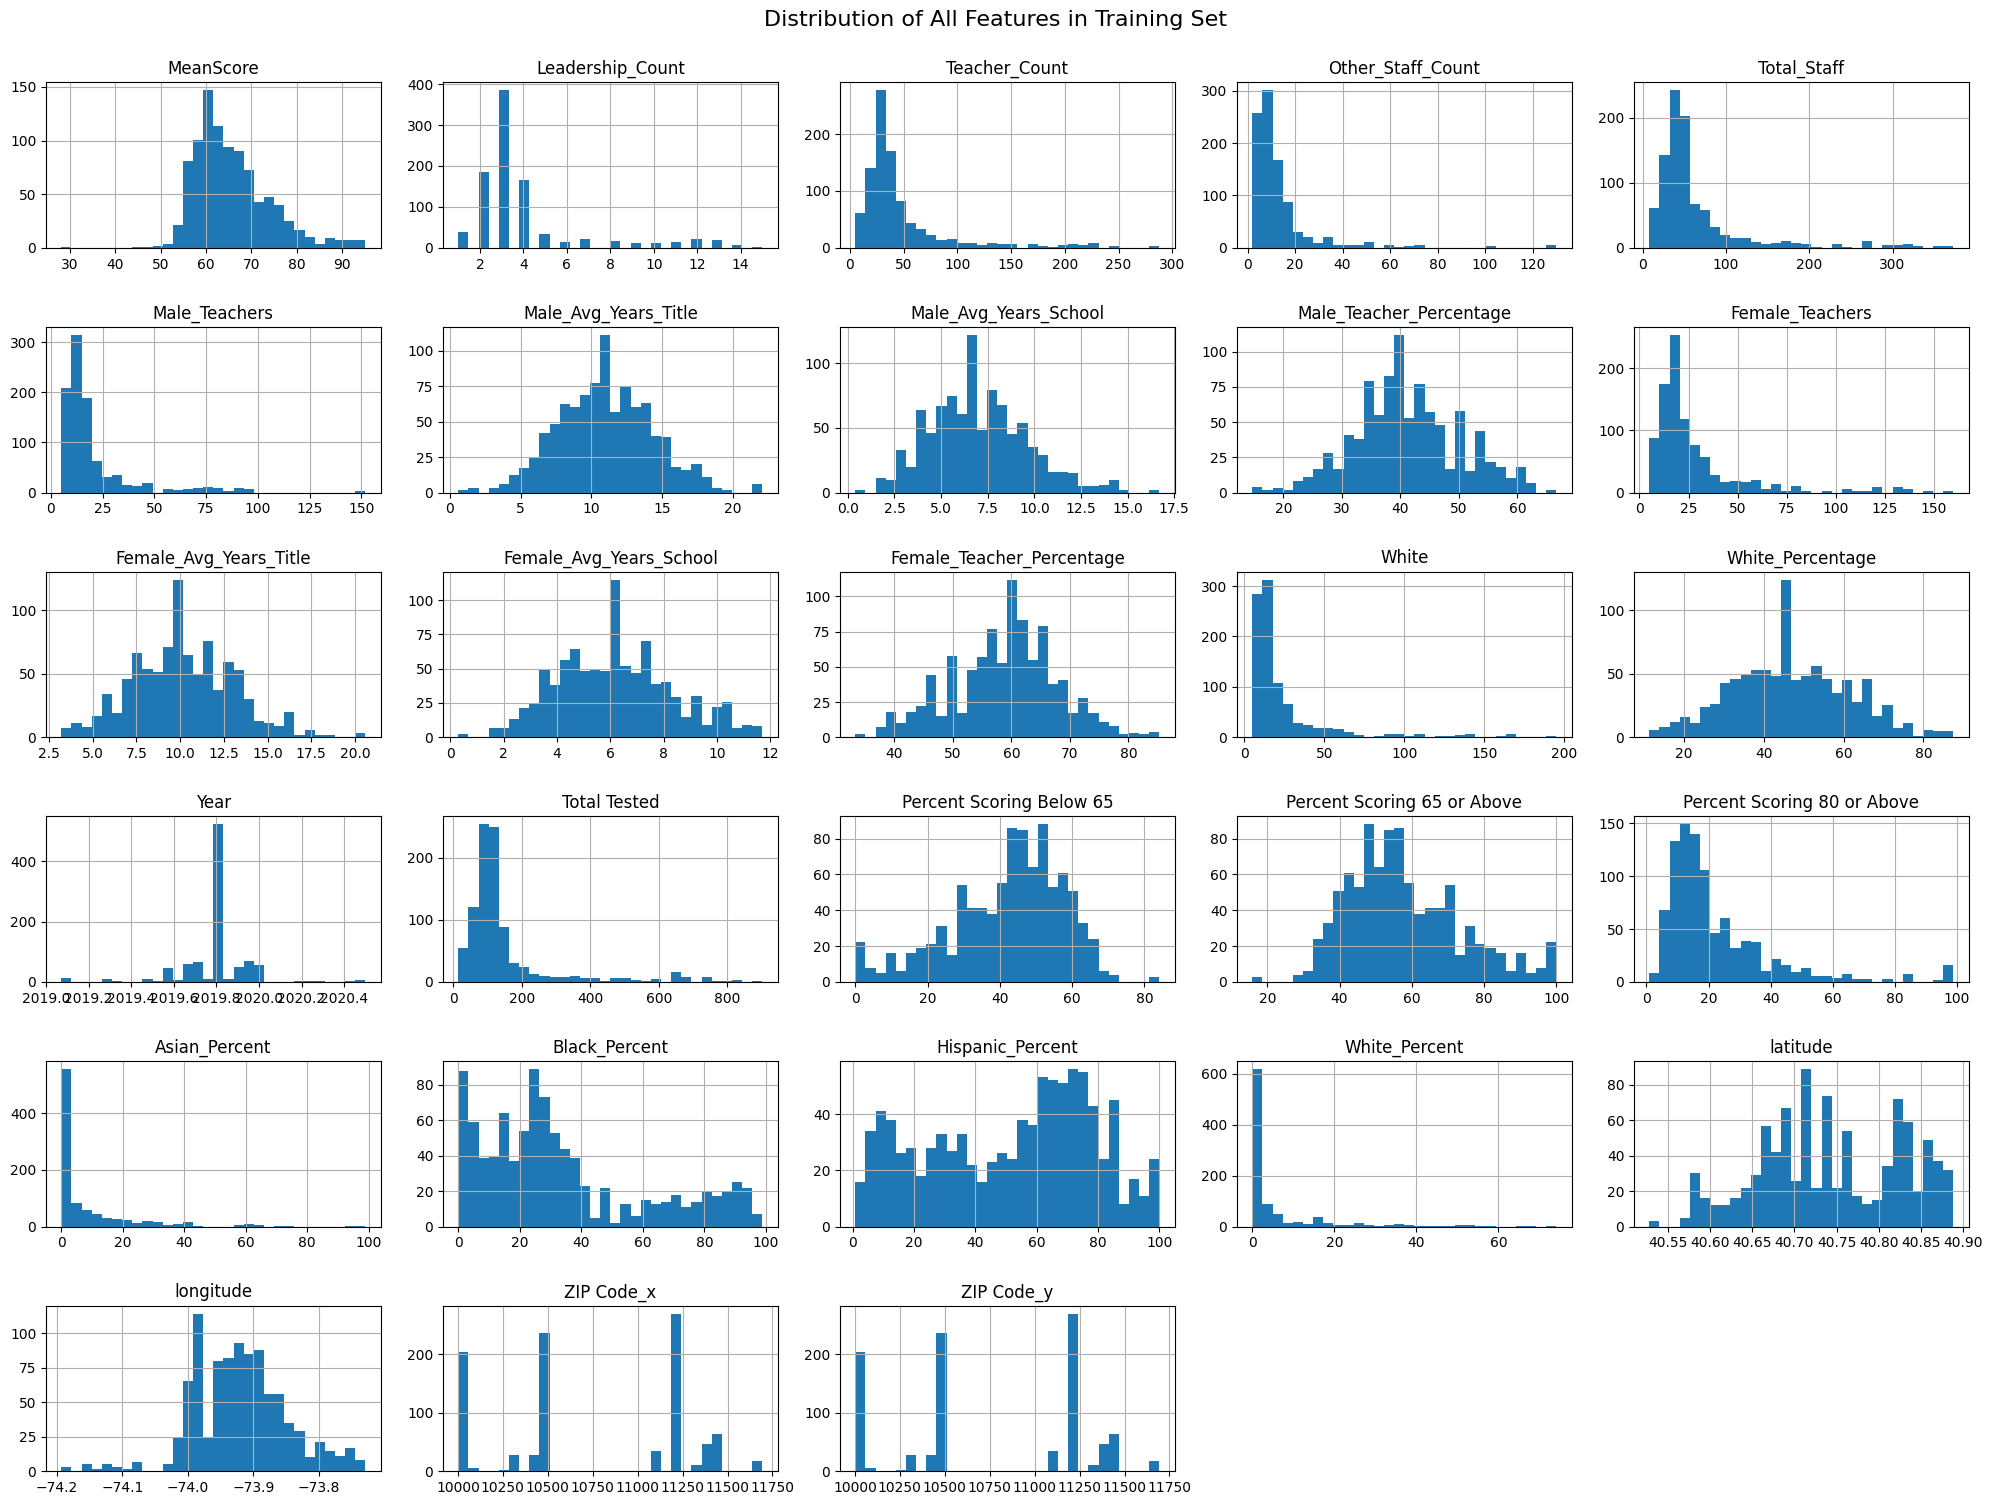

In [19]:
# Histogram of all numerical features in training set
train_set.hist(bins=30, figsize=(20, 15))
plt.suptitle('Distribution of All Features in Training Set', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

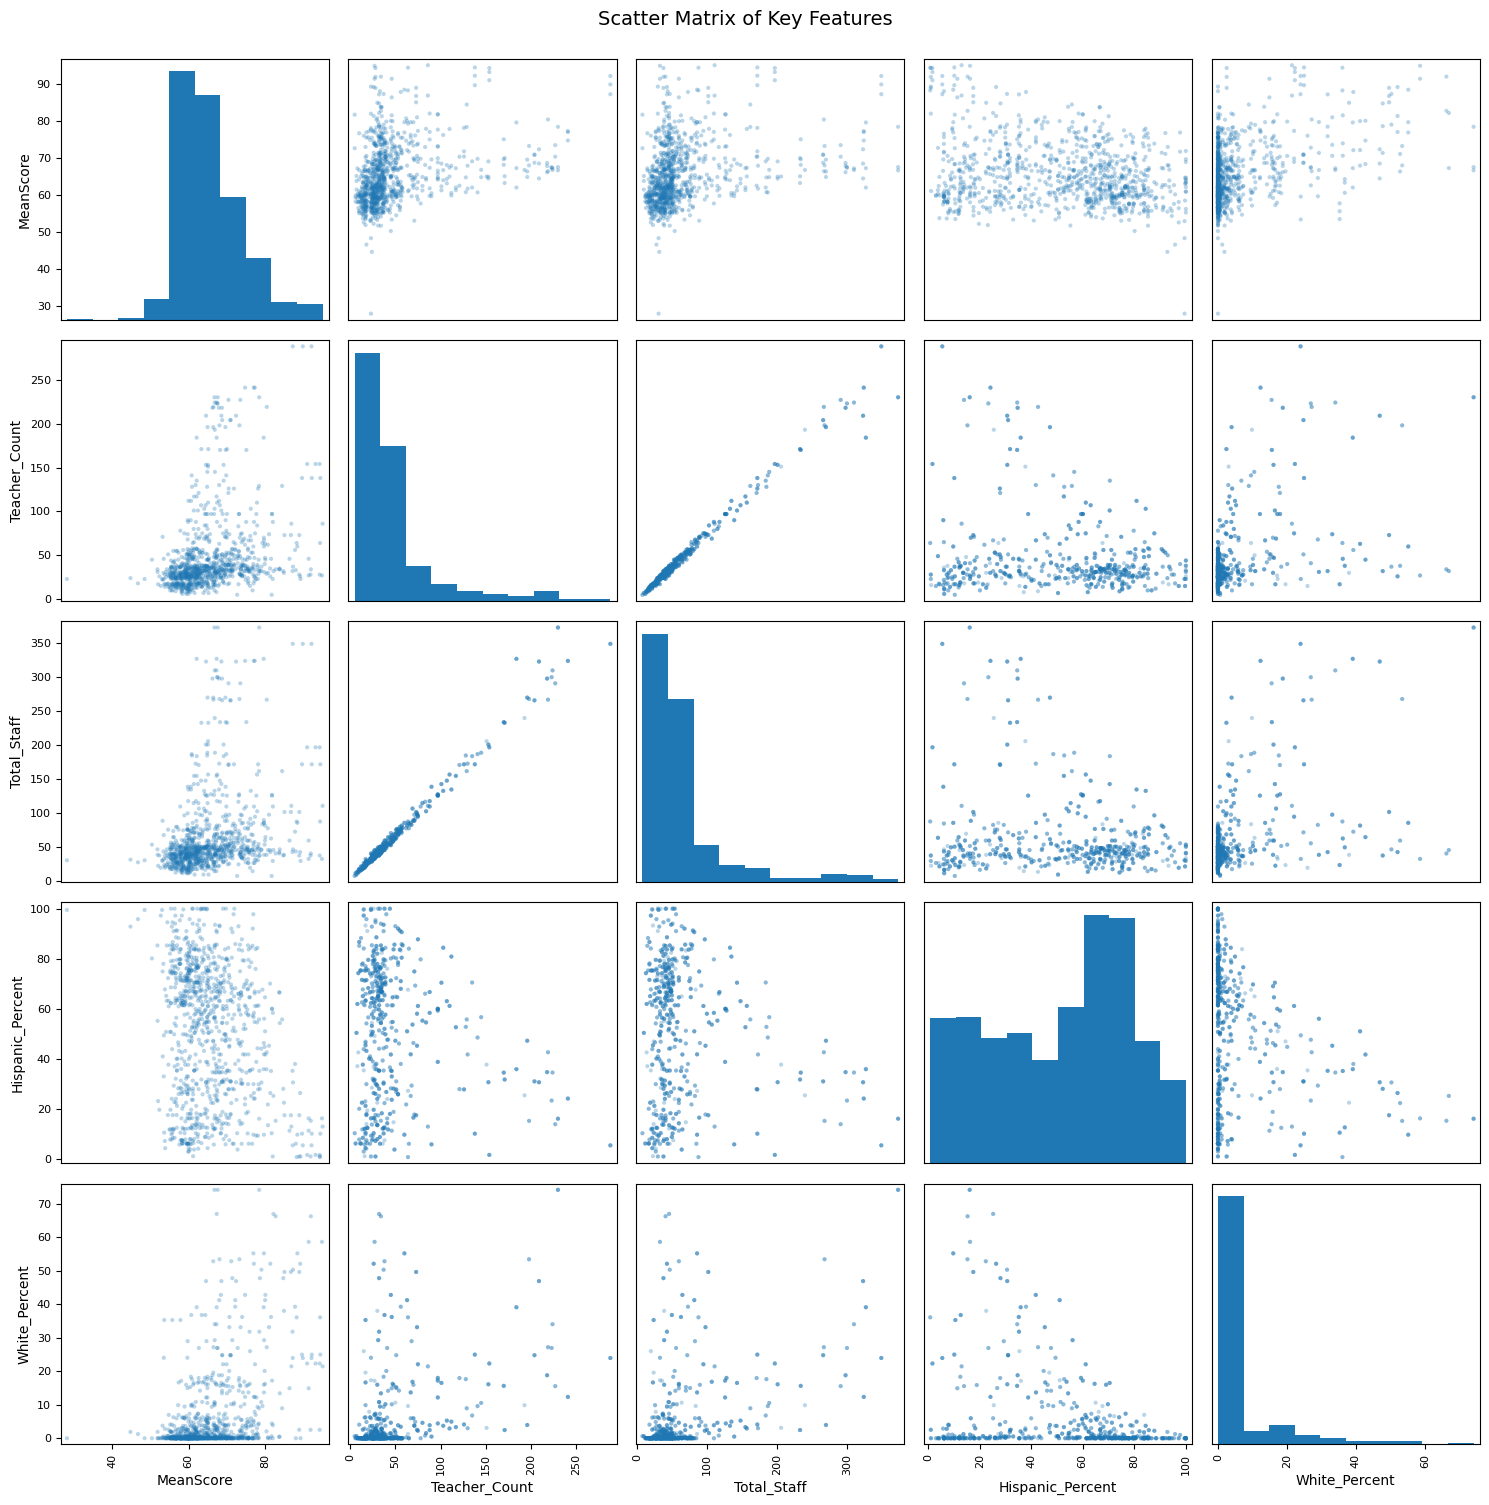

In [20]:
# Scatter matrix of selected features
scatter_features = ['MeanScore', 'Teacher_Count', 'Total_Staff', 'Hispanic_Percent', 'White_Percent']
scatter_matrix(train_set[scatter_features], figsize=(15, 15), alpha=0.3)
plt.suptitle('Scatter Matrix of Key Features', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Feature Transformations

## Transformations for MeanScore

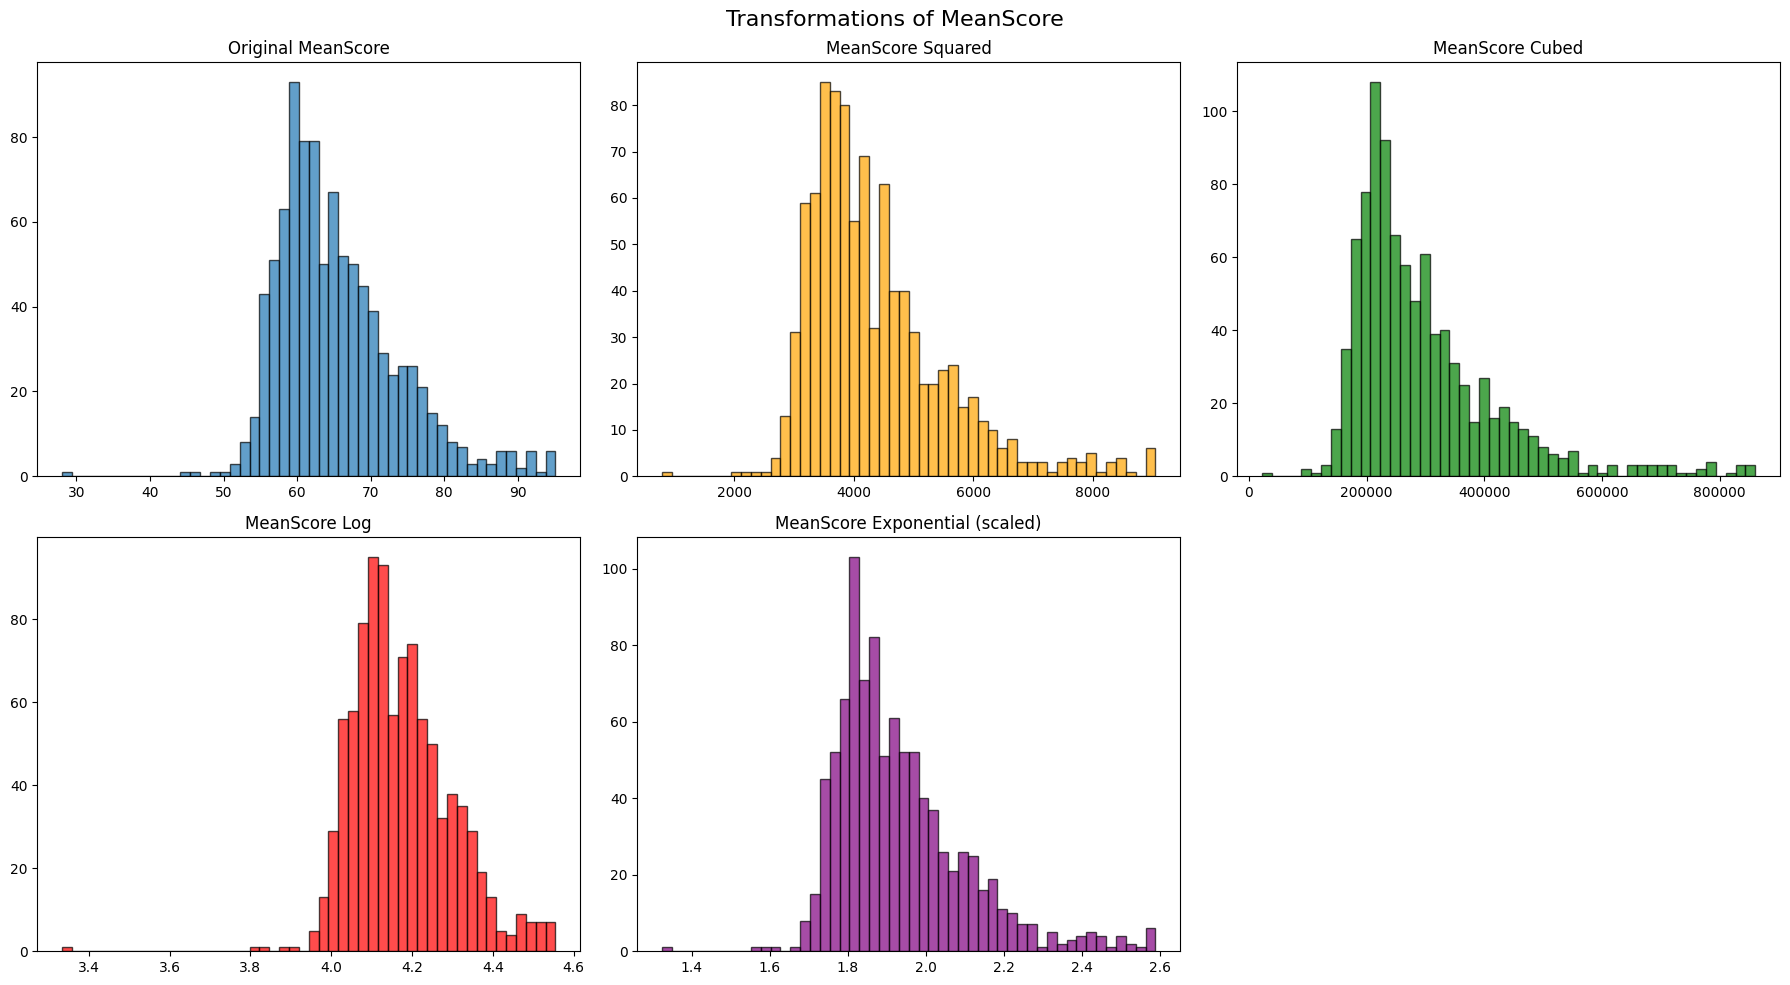

In [21]:
# Apply transformations to MeanScore
feature1 = 'MeanScore'
train_set[f'{feature1}_squared'] = train_set[feature1] ** 2
train_set[f'{feature1}_cubed'] = train_set[feature1] ** 3
train_set[f'{feature1}_log'] = np.log(train_set[feature1])
train_set[f'{feature1}_exp'] = np.exp(train_set[feature1] / 100)  # Scaled down to avoid overflow

# Plot histograms for MeanScore transformations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Transformations of {feature1}', fontsize=16)

axes[0, 0].hist(train_set[feature1], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title(f'Original {feature1}')

axes[0, 1].hist(train_set[f'{feature1}_squared'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title(f'{feature1} Squared')

axes[0, 2].hist(train_set[f'{feature1}_cubed'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title(f'{feature1} Cubed')

axes[1, 0].hist(train_set[f'{feature1}_log'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].set_title(f'{feature1} Log')

axes[1, 1].hist(train_set[f'{feature1}_exp'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title(f'{feature1} Exponential (scaled)')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## Transformations for Teacher_Count

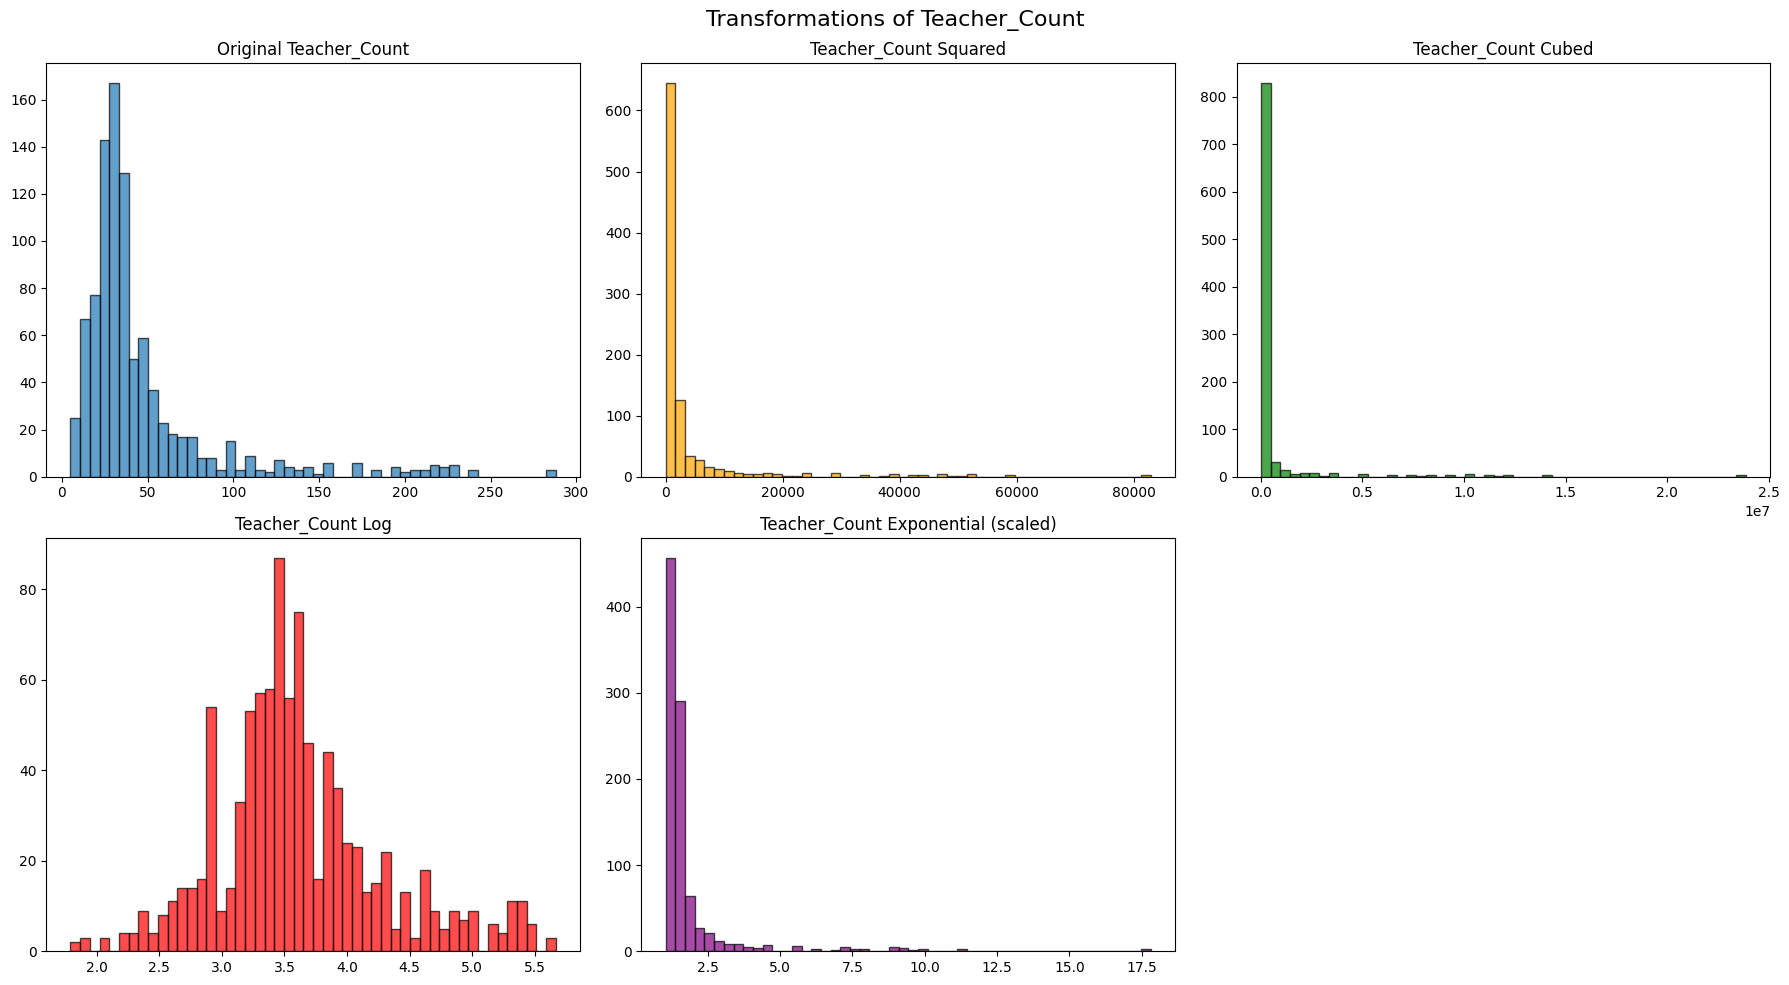

In [22]:
# Apply transformations to Teacher_Count
feature2 = 'Teacher_Count'
train_set[f'{feature2}_squared'] = train_set[feature2] ** 2
train_set[f'{feature2}_cubed'] = train_set[feature2] ** 3
train_set[f'{feature2}_log'] = np.log(train_set[feature2] + 1)
train_set[f'{feature2}_exp'] = np.exp(train_set[feature2] / 100)  # Scaled down to avoid overflow

# Plot histograms for Teacher_Count transformations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Transformations of {feature2}', fontsize=16)

axes[0, 0].hist(train_set[feature2], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title(f'Original {feature2}')

axes[0, 1].hist(train_set[f'{feature2}_squared'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title(f'{feature2} Squared')

axes[0, 2].hist(train_set[f'{feature2}_cubed'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title(f'{feature2} Cubed')

axes[1, 0].hist(train_set[f'{feature2}_log'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].set_title(f'{feature2} Log')

axes[1, 1].hist(train_set[f'{feature2}_exp'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title(f'{feature2} Exponential (scaled)')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## Scatter Matrices with Transformations

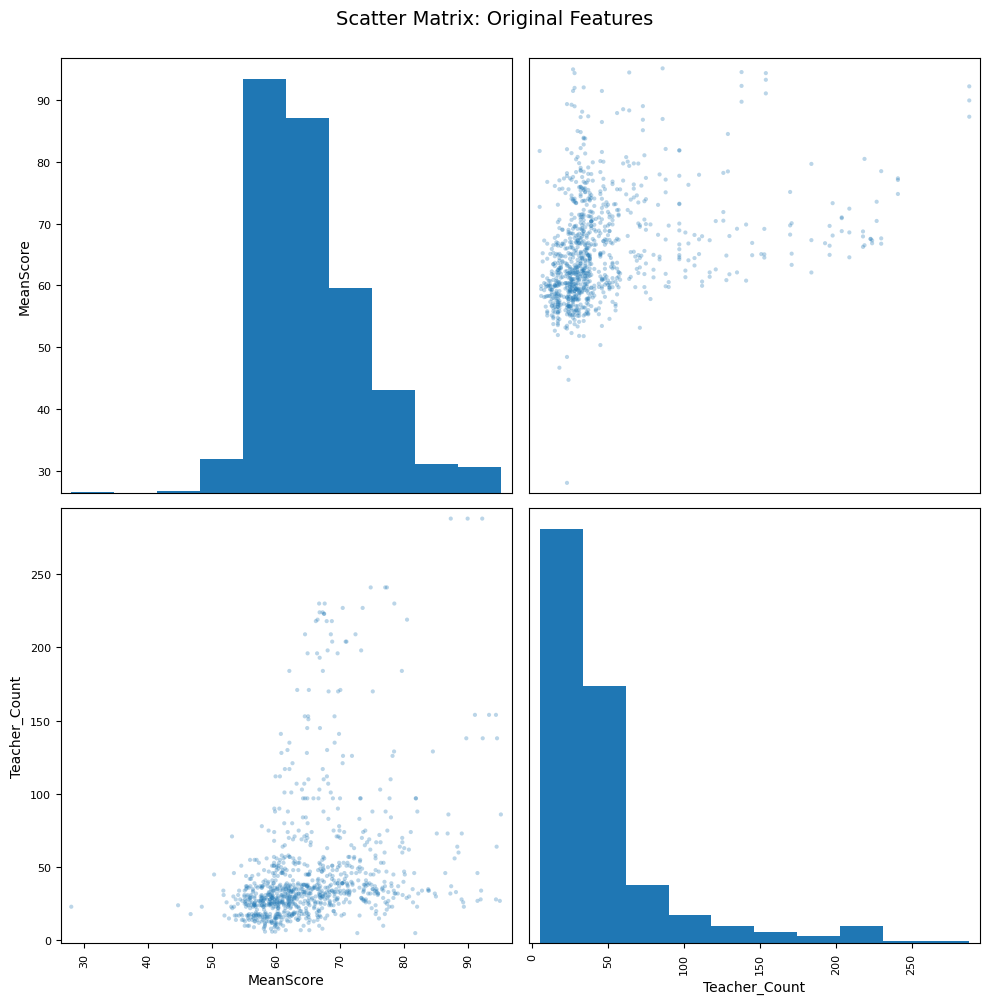

In [23]:
# Scatter matrix for original features
original_features = ['MeanScore', 'Teacher_Count']
scatter_matrix(train_set[original_features], figsize=(10, 10), alpha=0.3)
plt.suptitle('Scatter Matrix: Original Features', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

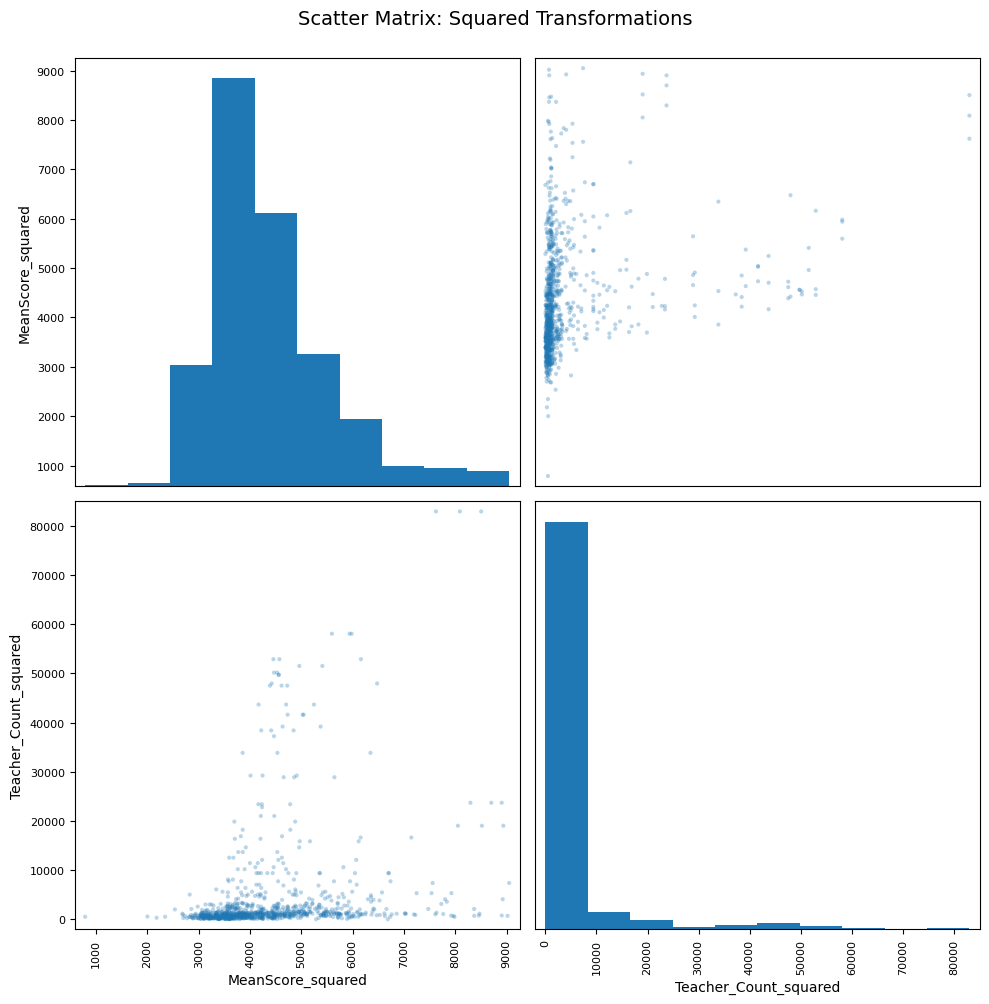

In [24]:
# Scatter matrix for squared transformations
squared_features = ['MeanScore_squared', 'Teacher_Count_squared']
scatter_matrix(train_set[squared_features], figsize=(10, 10), alpha=0.3)
plt.suptitle('Scatter Matrix: Squared Transformations', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

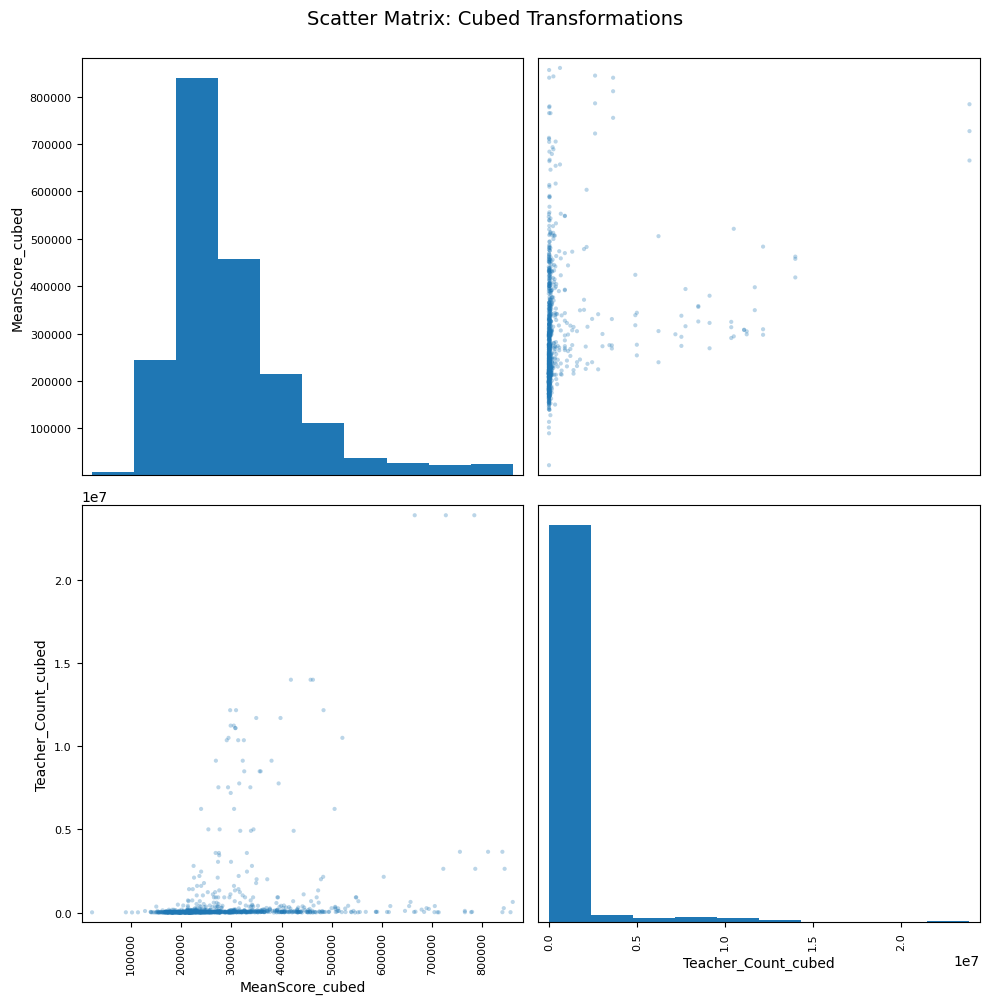

In [25]:
# Scatter matrix for cubed transformations
cubed_features = ['MeanScore_cubed', 'Teacher_Count_cubed']
scatter_matrix(train_set[cubed_features], figsize=(10, 10), alpha=0.3)
plt.suptitle('Scatter Matrix: Cubed Transformations', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

# Save Cleaned Datasets

# Summary and Conclusions

## Dataset Summary:
- **Original size:** 1,183 rows, 40 columns
- **Target variable:** Subject (3 classes: common_core_algebra, common_core_english, living_environment)
- **Features:** School demographics, staff statistics, student demographics, test scores
- **Training set:** 946 rows
- **Test set:** 237 rows

## Key Findings:
1. **Missing Values:** Handled using median imputation for numerical features
2. **Class Balance:** Dataset is balanced across the three subjects (equal distribution)
3. **Feature Distributions:**
   - MeanScore: Approximately normal distribution centered around 65-70
   - Teacher_Count: Right-skewed distribution with most schools having 40-60 teachers
   - Demographics show high variability across schools

4. **Transformation Effects:**
   - Log transformation helps normalize skewed distributions
   - Squared and cubed transformations amplify differences between high and low values
   - These transformations may be useful for modeling non-linear relationships